In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
sns.set_theme(style="whitegrid")


In [9]:
DB_PATH = f"results.sqlite"
type = "text"
TABLE_WITH_CLONE = f"{type}_with_clone"
TABLE_WITHOUT_CLONE = f"{type}_without_clone"

type = "text"
df_win_rates = pd.read_csv("parsed_heatmaps/" + type + "_win_rates.csv", index_col=0)
df_battle_counts = pd.read_csv("parsed_heatmaps/" + type + "_battle_counts.csv", index_col=0)

M = len(df_win_rates)
model_names = list(df_win_rates.index)


In [10]:
def load_all(table, db_path="results.sqlite"):
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql(f"SELECT * FROM {table}", conn)

df_with_clone = load_all(TABLE_WITH_CLONE)
df_without_clone = load_all(TABLE_WITHOUT_CLONE)


/tmp/ipykernel_78533/1368583925.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=90)


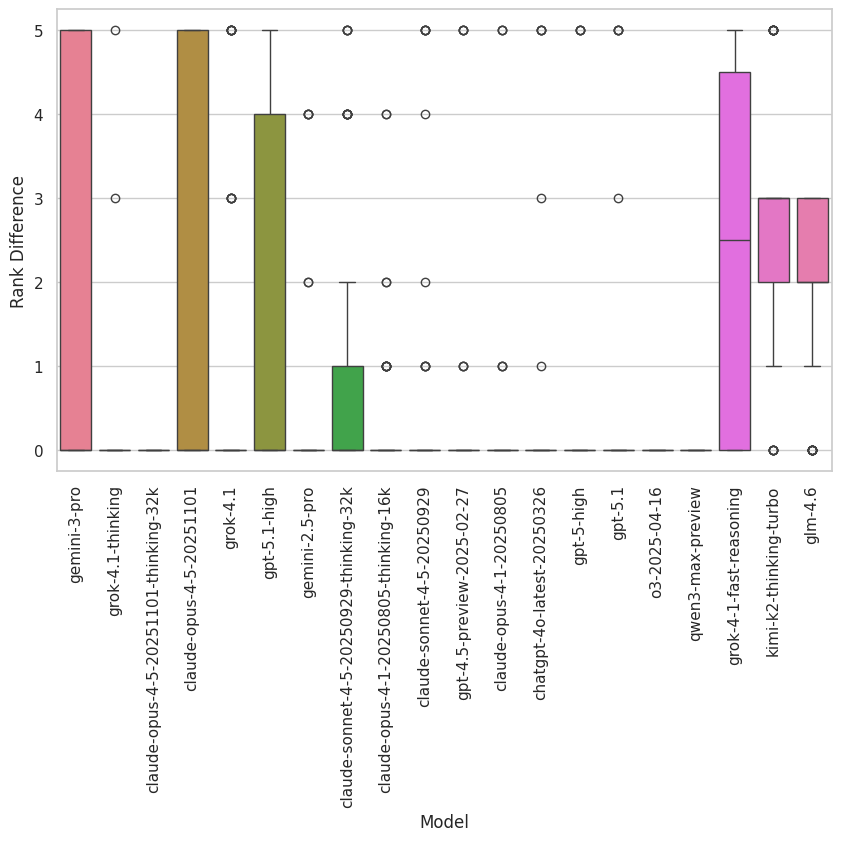

In [11]:
def plot_ranks(df_with_clone, df_without_clone):
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=df_without_clone - df_with_clone, ax=ax)
    ax.set_xlabel("Model")
    ax.set_ylabel("Rank Difference")
    ax.set_xticklabels(model_names, rotation=90)
    plt.show()

plot_ranks(df_with_clone, df_without_clone)